In [1]:
import numpy as np
import math
import h5py
import sys
from sys import argv, exit
import configparser
from mpi4py import MPI
import meep as mp
import os
from numpy import array
from matplotlib.colors import LogNorm

from os.path import join
from matplotlib import pyplot as pl
from scipy.signal import butter, lfilter
import utils_CFM
import util_nuRadioMC

from pathlib import Path
import utils_CFM
#from utils_CFM import fluence, get_2peaks, shift_t

sys.path.append('../../')
from paraPropPython import paraProp as ppp
import receiver as rx
from transmitter import tx_signal
from data import create_sim, create_rxList_from_file, create_tx_signal, create_transmitter_array
from data import create_hdf_bscan, bscan_rxList, create_hdf_FT
import util
from util import cut_arr2, cut_arr, findNearest
from data import ascan

def getNearest(y_arr, x_arr, x):
    ii = findNearest(x_arr, x)
    return y_arr[ii]

from fluence_analysis import *

Using MPI version 4.0, 1 processes
CPP version of ray tracer is available


In [2]:
def get_fluence_arr_from_config(fname_config):
    ppp_data = get_sim_ppp(fname_config)
    ascan_ppp_l, tspace_ppp0, rxList_ppp0, sourceDepth_ppp0 = ppp_data
    
    nRx0 = len(rxList_ppp0)
    nSims = len(ascan_ppp_l)
    nSamples = len(tspace_ppp0)

    rxFluence_arr = np.zeros((nSims, nRx0))
    for i in range(nSims):
        ascan_ppp_i = ascan_ppp_l[i]
        rxPulses_arr = ascan_ppp_i.ascan_array
        for j in range(nRx0):
            rxFluence_arr[i,j] = fluence(abs(rxPulses_arr[0,j]), tspace_ppp0)
    return rxFluence_arr, rxList_ppp0, tspace_ppp0

def get_fluence_var_arr(rxFluence_arr):
    nRx = rxFluence_arr.shape[1]
    for i in range(nRx):
        rxFluence_var[i] = np.nanstd(rxFluence_arr[:,i])/np.nanmean(rxFluence_arr[:,i])
    return rxFluence_var    
#plot_fluence_arr

def get_fluence_at_depth_local(rxFluence, rxList, z_rx):
    x_rx_all = rxList[:,0]
    z_rx_all = rxList[:,1]
    x_rx_un = np.unique(x_rx_all)
    z_rx_un = np.unique(z_rx_all)

    ii_z = util.findNearest(z_rx_un, z_rx)
    z_rx_actual = z_rx_un[ii_z]
        
    nRx_x = len(x_rx_un)
    nSims = rxFluence.shape[0]
    if len(rxFluence.shape) == 3:
        nShape = 2
        rxFluence_at_z = np.zeros((nSims, nRx_x,2))
    else:
        nShape = 1
        rxFluence_at_z = np.zeros((nSims, nRx_x))
    for i in range(nRx_x):
        ii_rx = utils_CFM.get_index_from_rxList(rxList, x_rx_un[i], z_rx_actual)
        if nShape == 1:
            rxFluence_at_z[:,i] = rxFluence[:,ii_rx]
        else:
            rxFluence_at_z[:,i,:] = rxFluence[:,ii_rx,:]
    return rxFluence_at_z, x_rx_un, z_rx_actual

In [3]:
fname_config0 = 'config_files/config_analysis_askaryan_500_ppp_dtheta3.txt'
rxFluence_arr0, rxList_ppp0, tspace_ppp0 = get_fluence_arr_from_config(fname_config0)

nHalf =  7199
[90.]
nHalf =  7199
nHalf =  7199
nHalf =  7199
nHalf =  7199


In [4]:
fname_config1 = 'config_files/config_analysis_askaryan_500_ppp_dtheta7.txt'
rxFluence_arr1, rxList_ppp1, tspace_ppp1 = get_fluence_arr_from_config(fname_config1)

nHalf =  7199
[90.]
nHalf =  7199
nHalf =  7199
nHalf =  7199
nHalf =  7199


In [5]:
fname_config2 = 'config_files/config_analysis_askaryan_500_ppp_dtheta5.txt'
rxFluence_arr2, rxList_ppp2, tspace_ppp2 = get_fluence_arr_from_config(fname_config2)

nHalf =  7199
[90.]
nHalf =  7199
nHalf =  7199
nHalf =  7199
nHalf =  7199


In [6]:
z_rx = 100
rxFluence_at_z0, x_rx_un, z_rx_true = get_fluence_at_depth_local(rxFluence=rxFluence_arr0, rxList=rxList_ppp0, z_rx=z_rx)
rxFluence_at_z1, x_rx_un, z_rx_true = get_fluence_at_depth_local(rxFluence=rxFluence_arr1, rxList=rxList_ppp1, z_rx=z_rx)
rxFluence_at_z2, x_rx_un, z_rx_true = get_fluence_at_depth_local(rxFluence=rxFluence_arr2, rxList=rxList_ppp1, z_rx=z_rx)

In [7]:
rxFluence_l = [rxFluence_at_z0, rxFluence_at_z1, rxFluence_at_z2]

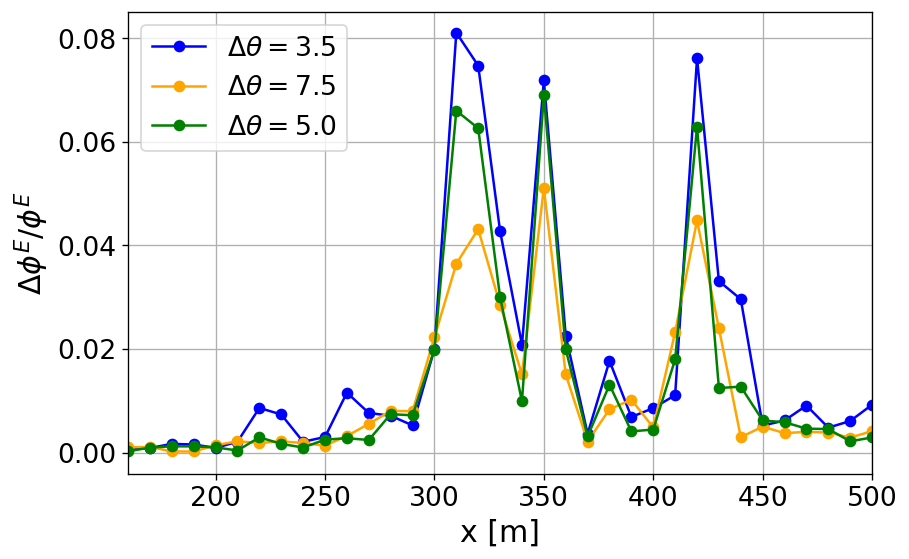

In [8]:
'''
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
color_l = ['b', 'g', 'purple']
label_l = ['dtheta3.5', 'dtheta7.5', 'dtheta5.0']
for i in range(len(rxFluence_l)):
    rxFluence_var_at_z = []
    for j in range(len(x_rx_un)):
        rxFluence_var_zx = np.nanstd(rxFluence_l[i][:,j])/np.nanmean(rxFluence_l[i][:,j])
        rxFluence_var_at_z.append(rxFluence_var_zx)
    ax.plot(x_rx_un, rxFluence_var_at_z, '-o', c=color_l[i],label=label_l[i])
ax.grid()
ax.set_yscale('log')
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('$\Delta \phi^{E}/\phi^{E}$')
fig.savefig('compare_fluence_var_dtheta_log.png')
pl.show()
'''
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
color_l = ['b', 'orange', 'g']
label_l = [r'$\Delta \theta = 3.5$', r'$\Delta \theta = 7.5$', r'$\Delta \theta = 5.0$']
rxFluence_var_l = []
rxFluence_var_spread_l = []

for i in range(len(rxFluence_l)):
    rxFluence_var_at_z = []
    rxFluence_var_at_z_cut = []
    for j in range(len(x_rx_un)):
        rxFluence_var_zx = np.nanstd(rxFluence_l[i][:,j])/np.nanmean(rxFluence_l[i][:,j])
        rxFluence_var_at_z.append(rxFluence_var_zx)
        if x_rx_un[j] > 300 and x_rx_un[j] < 450:
            rxFluence_var_at_z_cut.append(rxFluence_var_zx)
    ax.plot(x_rx_un, rxFluence_var_at_z, '-o', c=color_l[i],label=label_l[i])
    rxFluence_var_l.append(np.mean(rxFluence_var_at_z_cut))
    rxFluence_var_spread_l.append(np.std(rxFluence_var_at_z_cut)/np.sqrt(len(rxFluence_var_at_z_cut)))
ax.grid()
#ax.set_yscale('log')
ax.legend(fontsize=16)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('x [m]',fontsize=18)
ax.set_ylabel('$\Delta \phi^{E}/\phi^{E}$',fontsize=18)
ax.set_xlim(160,500)

fig.savefig('compare_fluence_var_dtheta_lin.png', bbox_inches='tight')
pl.show()

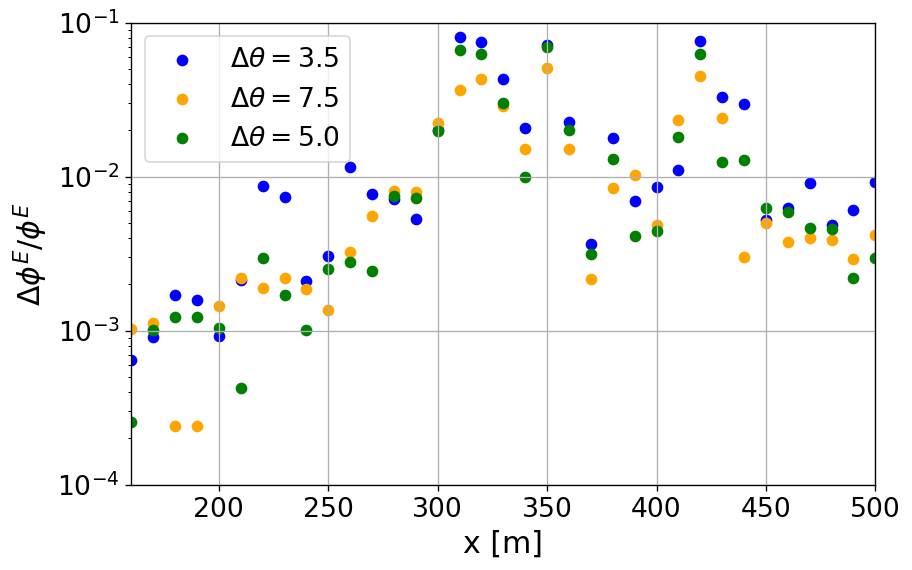

In [9]:
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
color_l = ['b', 'orange', 'g']
label_l = [r'$\Delta \theta = 3.5$', r'$\Delta \theta = 7.5$', r'$\Delta \theta = 5.0$']
rxFluence_var_l = []

for i in range(len(rxFluence_l)):
    rxFluence_var_at_z = []
    for j in range(len(x_rx_un)):
        rxFluence_var_zx = np.nanstd(rxFluence_l[i][:,j])/np.nanmean(rxFluence_l[i][:,j])
        rxFluence_var_at_z.append(rxFluence_var_zx)
    ax.scatter(x_rx_un, rxFluence_var_at_z, c=color_l[i],label=label_l[i])
    rxFluence_var_l.append(np.mean(rxFluence_var_at_z))
ax.grid()
ax.set_yscale('log')
ax.set_xlim(160,500)
ax.legend(fontsize=16)
ax.set_ylim(1e-4,1e-1)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('x [m]',fontsize=18)
ax.set_ylabel('$\Delta \phi^{E}/\phi^{E}$',fontsize=18)
fig.savefig('compare_fluence_var_dtheta_log.png', bbox_inches='tight')
pl.show()

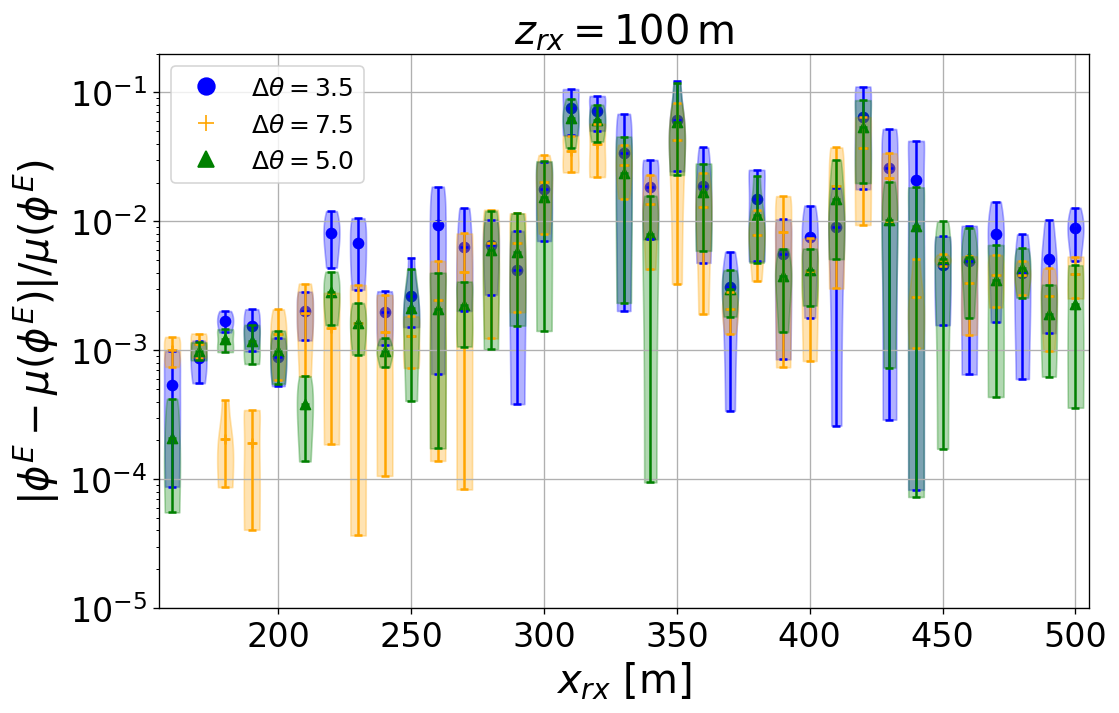

In [15]:
fig = pl.figure(figsize=(10,6),dpi=120)
ax = fig.add_subplot(111)
color_l = ['b', 'orange', 'g']
label_l = [r'$\Delta \theta = 3.5$', r'$\Delta \theta = 7.5$', r'$\Delta \theta = 5.0$']
labels = []
marker_l = ['o','+', '^']

for i in range(len(rxFluence_l)):
    rxFluence_var_at_z = []
    for j in range(len(x_rx_un)):
        rxFluence_mean_x = np.nanmean(rxFluence_l[i][:,j])
        rxFleunce_residuals = abs((rxFluence_l[i][:,j]-rxFluence_mean_x)/rxFluence_mean_x)
        
        #rxFluence_var_zx = np.nanstd(rxFluence_l[i][:,j])/np.nanmean(rxFluence_l[i][:,j])
        rxFluence_var_at_z.append(rxFleunce_residuals)
        ax.scatter(x_rx_un[j], np.mean(rxFleunce_residuals), c=color_l[i], marker=marker_l[i])
    vio = ax.violinplot(dataset=rxFluence_var_at_z, positions=x_rx_un, showmeans=True,widths=6)
    for partname in ('cmeans', 'cmins', 'cmaxes', 'cbars'):
        vp_line = vio.get(partname)
        if vp_line is not None:
            if isinstance(vp_line, list):
                for line in vp_line:
                    line.set_color(color_l[i])
            else:
                vp_line.set_color(color_l[i])
    for pc in vio['bodies']:
        pc.set_facecolor(color_l[i])
        pc.set_edgecolor(color_l[i])
    label_i = label_l[i]
    add_label(vio, label_i,labels)
ax.set_title('$z_{rx} = 100 \, \mathrm{m}$',fontsize=24)
ax.grid()
'''
group_proxies = []

for i in range(3):
    # after styling the violin:
    group_proxies.append(
        mpatches.Patch(facecolor=color_l[i], edgecolor=color_l[i], label=label_l[i])
    )
'''
from matplotlib.lines import Line2D
group_proxies = []
for i in range(3):
    group_proxies.append(
        Line2D([0], [0],
               marker=marker_l[i],
               color='none',              # no line
               markerfacecolor=color_l[i],
               markeredgecolor=color_l[i],
               markersize=10,
               linestyle='None',
               label=label_l[i])
    )

line_handles, line_labels = ax.get_legend_handles_labels()  # includes axvline's
handles = group_proxies + line_handles
labels  = [p.get_label() for p in group_proxies] + line_labels
ax.set_yscale('log')
ax.set_xlim(155,505)
ax.set_ylim(1e-5, 2e-1)
ax.set_xlabel('$x_{rx}$ [m]',fontsize=24)
ax.set_ylabel('$|\phi^{E}-\mu(\phi^{E})|/\mu(\phi^{E})$',fontsize=24)
ax.legend(handles, labels, fontsize=15, loc='upper left')
ax.tick_params(labelsize=20)
fig.savefig('rx_tot_fluence_vio_bandwidth.png',bbox_inches='tight')
pl.show()

In [11]:
'''
fname_l0 = get_fname_l(fname_config0)
fname_l1 = get_fname_l(fname_config1)
fname_l2 = get_fname_l(fname_config2)
'''
fname_l0, label_l0 = get_fname_l(fname_config0)
fname_l1, label_l1 = get_fname_l(fname_config1)
fname_l2, label_l2 = get_fname_l(fname_config2)

print(fname_l0)
ascan_0 = ascan()
ascan_0.load_from_hdf(fname_l0[0])

ascan_1 = ascan()
ascan_1.load_from_hdf(fname_l1[0])

ascan_2 = ascan()
ascan_2.load_from_hdf(fname_l2[0])

['data_ppp_old/CFM_study_500m_160m_meep_compare/CFM_study_600m_220m_dtheta35/nProf_CFM_2014_1.h5', 'data_ppp_old/CFM_study_500m_160m_meep_compare/CFM_study_600m_220m_dtheta35/nProf_CFM_2014_3.h5', 'data_ppp_old/CFM_study_500m_160m_meep_compare/CFM_study_600m_220m_dtheta35/nProf_CFM_2014_5.h5', 'data_ppp_old/CFM_study_500m_160m_meep_compare/CFM_study_600m_220m_dtheta35/nProf_CFM_2014_7.h5']
nHalf =  7199
nHalf =  7199
nHalf =  7199


fmin = 0.0766613425925926 fmax = 0.6032914351851851 B =  0.5266300925925925 $\Delta \theta = 3.5$
fmin = 0.03777515432098765 fmax = 0.28997986111111107 B =  0.2522047067901234 $\Delta \theta = 7.5$
fmin = 0.055273939043209874 fmax = 0.4291368634259259 B =  0.373862924382716 $\Delta \theta = 5.0$


/home/alxok/miniconda3/lib/python3.11/site-packages/numpy/fft/_pocketfft.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  r = pfi.execute(a, is_real, is_forward, fct)


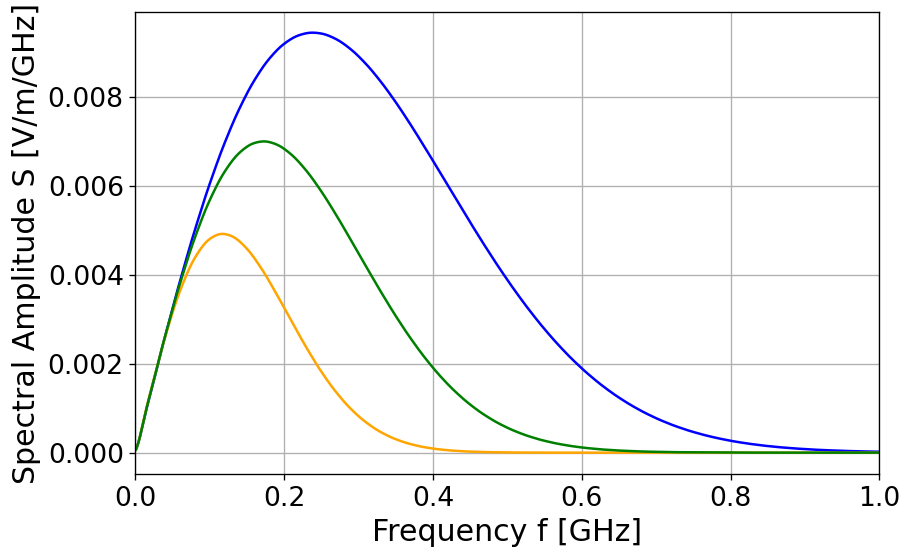

In [12]:
fmax_l = []
fmin_l = []

ascan_0_l = [ascan_0, ascan_1, ascan_2]
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
for i in range(len(ascan_0_l)):
    tx_signal_i = ascan_0_l[i].tx_signal
    tx_pulse_i = tx_signal_i.pulse
    dt = tx_signal_i.dt
    nSamples_tx = len(tx_pulse_i)
    tspace_tx = np.linspace(0, nSamples_tx*dt, nSamples_tx)
    tx_spectrum = np.fft.rfft(tx_pulse_i)
    fspace_tx = np.fft.rfftfreq(nSamples_tx, dt)
    ax.plot(fspace_tx, abs(tx_spectrum),c=color_l[i],label=label_l[i])

    tx_cs = np.cumsum(abs(tx_spectrum))/np.sum(abs(tx_spectrum))
    ii_95 = util.findNearest(tx_cs, 0.95)
    fmax_95 = fspace_tx[ii_95]
    ii_05 = util.findNearest(tx_cs, 0.05)
    fmin_05 = fspace_tx[ii_05]
    fmax_l.append(fmax_95)
    fmin_l.append(fmin_05)
    B = fmax_95 - fmin_05
    print('fmin =', fmin_05,'fmax =', fmax_95, 'B = ', B, label_l[i])
ax.grid()
ax.set_xlabel('Frequency f [GHz]',fontsize=18)
ax.set_ylabel('Spectral Amplitude S [V/m/GHz]',fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0,1)
fig.savefig('spectra_3.png',bbox_inches='tight')
pl.show()

1.8104327799034673e-05


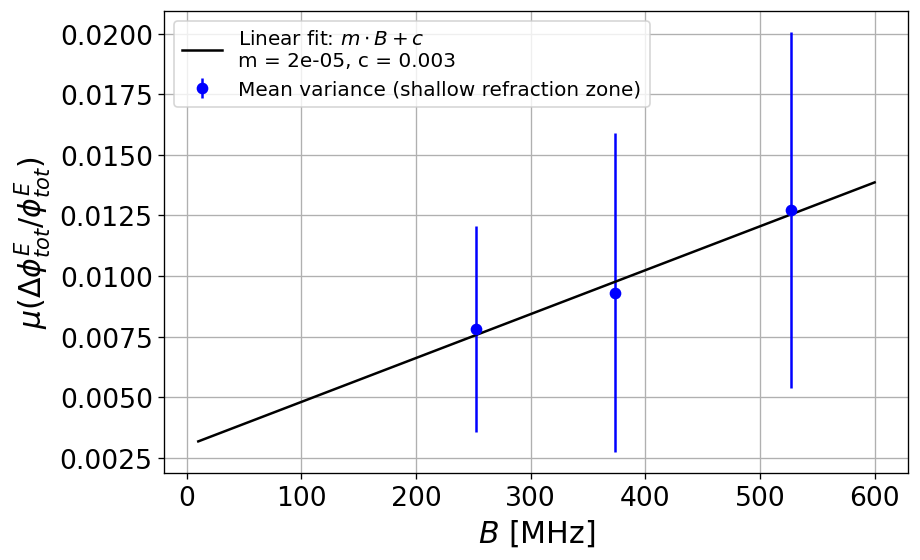

In [13]:
nSims = len(fmax_l)
band_l = np.zeros(nSims)
for i in range(nSims):
    band_l[i] = (fmax_l[i] - fmin_l[i])*1e3
#print(np.polyfit(band_l, rxFluence_var_l, 1))

p_fit = np.polyfit(band_l, rxFluence_var_l,1)
m = p_fit[0]
c = p_fit[1]
print(m)

band_space = np.linspace(10, 600, 1000)
fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
ax.errorbar(band_l, rxFluence_var_l, rxFluence_var_spread_l,fmt='o',label='Mean variance (shallow refraction zone)',c='b')
ax.plot(band_space, m*band_space + c,label='Linear fit: $m \cdot B + c$\nm = ' + str(round(m,5)) + ', c = ' + str(round(c,3)),c='k')
ax.grid()
ax.set_ylabel('$\mu(\Delta \phi^{E}_{tot}/\phi^{E}_{tot})$',fontsize=18)
ax.set_xlabel('$B$ [MHz]',fontsize=18)
ax.tick_params(labelsize=16,axis='both')
ax.legend(fontsize=12,loc='upper left')
fig.savefig('phi_var_band.png', bbox_inches='tight')
pl.show()

[[0.00000000e+00 1.83699496e-12 2.32528905e-12 ... 1.57558185e-12
  1.40862625e-12 1.26527576e-12]
 [4.22324122e-12 4.74528058e-12 5.42021699e-12 ... 2.93123004e-12
  2.62435189e-12 2.35966606e-12]
 [6.85634314e-12 7.08418314e-12 7.67569077e-12 ... 4.05828151e-12
  3.64499407e-12 3.28581934e-12]
 ...
 [2.12313482e-19 1.61016615e-19 6.03194147e-19 ... 1.64875558e-12
  1.40578593e-12 1.37779061e-12]
 [1.71983815e-19 1.20822524e-19 3.94820916e-19 ... 1.75140301e-12
  1.55619396e-12 1.39159419e-12]
 [1.05723411e-19 9.65531666e-20 3.02011775e-19 ... 2.77953717e-12
  2.08602849e-12 1.61664004e-12]]


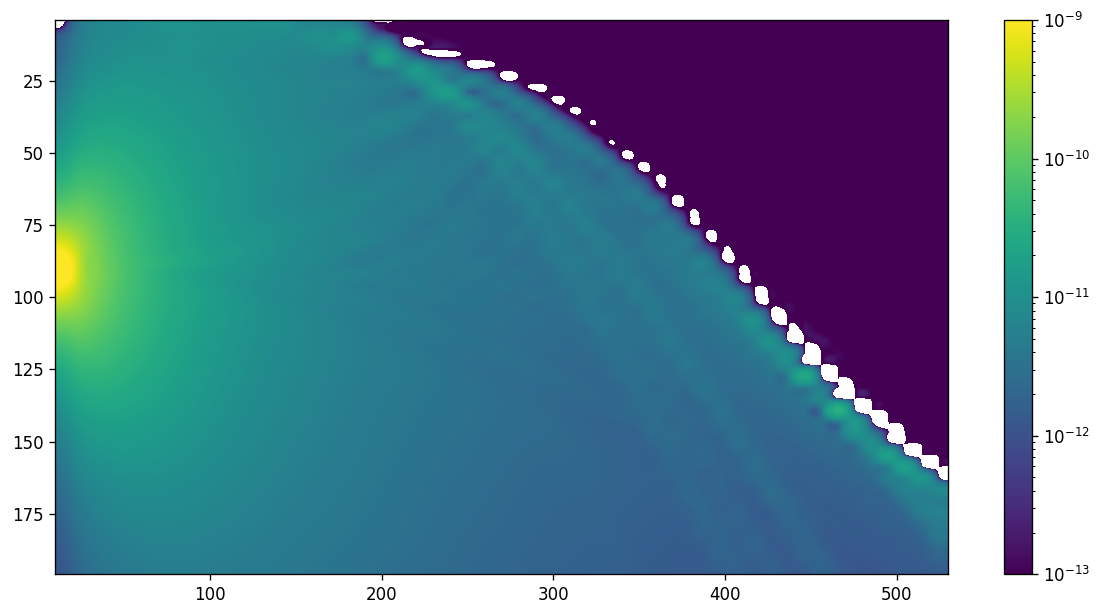

[[0.00000000e+00 5.15706726e-13 6.29974153e-13 ... 4.21150982e-13
  3.76385457e-13 3.37949026e-13]
 [1.13857004e-12 1.27180935e-12 1.45027921e-12 ... 7.90470413e-13
  7.07278723e-13 6.35604355e-13]
 [1.72441285e-12 1.84776720e-12 2.07136473e-12 ... 1.10138323e-12
  9.88574101e-13 8.90722914e-13]
 ...
 [5.96899286e-20 6.29292089e-20 1.59544840e-19 ... 4.89128264e-13
  4.41313717e-13 4.23980474e-13]
 [5.11127089e-20 4.72003081e-20 1.18588700e-19 ... 5.31089237e-13
  4.81035820e-13 4.08433545e-13]
 [3.90570020e-20 3.85573622e-20 9.24547342e-20 ... 8.48093607e-13
  6.51183527e-13 4.93493377e-13]]


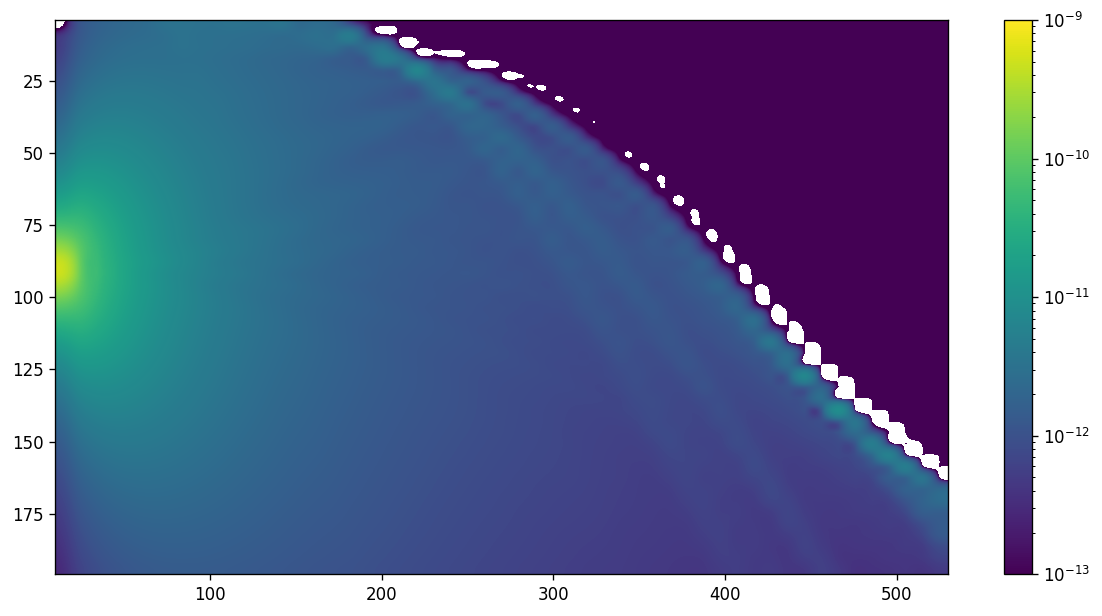

[[0.00000000e+00 1.01889338e-13 1.21483258e-13 ... 7.84733636e-14
  7.00752252e-14 6.28663017e-14]
 [2.11832184e-13 2.37998278e-13 2.74981726e-13 ... 1.49339077e-13
  1.33519803e-13 1.19903938e-13]
 [3.14071313e-13 3.44055085e-13 3.94015839e-13 ... 2.10407962e-13
  1.88605584e-13 1.69738592e-13]
 ...
 [1.92019421e-20 2.87056612e-20 5.93817278e-20 ... 1.09109056e-13
  1.01663396e-13 9.61534404e-14]
 [1.73973088e-20 2.06149396e-20 4.88324796e-20 ... 1.25157904e-13
  1.10804586e-13 9.17881733e-14]
 [1.58471167e-20 1.63244713e-20 3.99736858e-20 ... 1.92672055e-13
  1.47722142e-13 1.14936837e-13]]


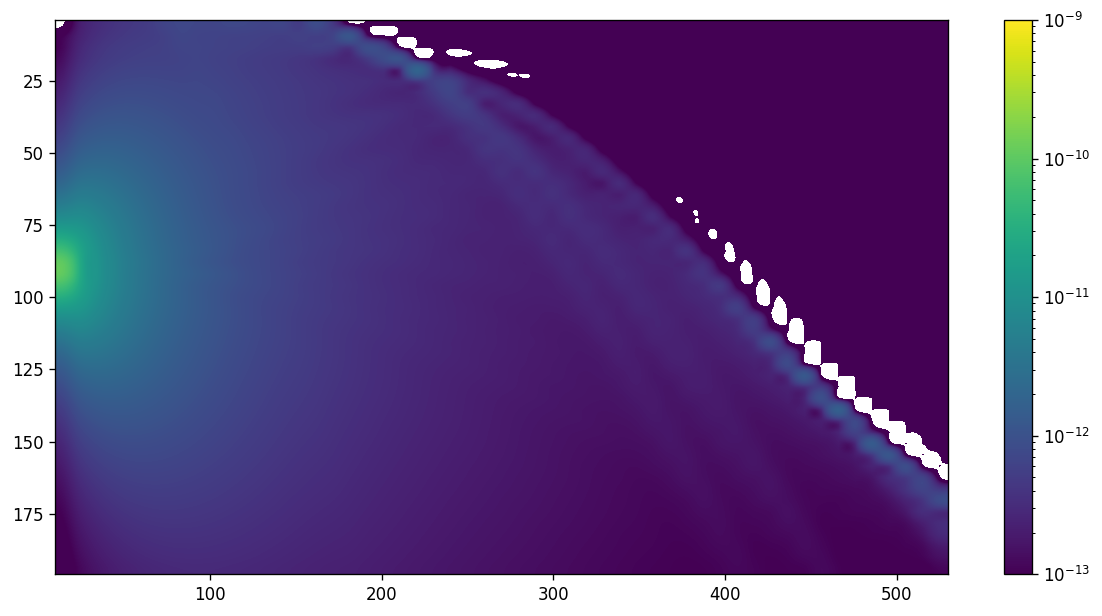

In [14]:
from matplotlib import colors as cm

def plot_fluence_map(rxFluence_arr, rxList):
    x_rx_arr = rxList[:,0]
    z_rx_arr = rxList[:,1]

    x_rx_un = np.unique(x_rx_arr)
    z_rx_un = np.unique(z_rx_arr)
    nBins_x = len(x_rx_un)
    nBins_z = len(z_rx_un)
    hist2d_arr, x_bins, z_bins = np.histogram2d(x_rx_arr, z_rx_arr, bins=(nBins_x, nBins_z), weights=rxFluence_arr[0,:])
    print(hist2d_arr)
    hist2d_arr = np.transpose(hist2d_arr)

    fig = pl.figure(figsize=(12,6),dpi=120)
    ax = fig.add_subplot(111)
    pmesh = ax.imshow(hist2d_arr, extent=[x_bins[0], x_bins[-1], z_bins[-1], z_bins[0]], aspect='auto',interpolation='spline16',norm=cm.LogNorm(vmin=1e-13,vmax=1e-9))
    fig.colorbar(pmesh)
    pl.show()


def plot_fluence_var_map(rxFluence_arr, rxList):
    x_rx_arr = rxList[:,0]
    z_rx_arr = rxList[:,1]
    nRx = rxFluence_arr.shape[1]
    rxFluence_var = np.zeros(nRx)
    for i in range(nRx):
        rxFluence_var[i] = np.nanstd(rxFluence_arr[:,i])/np.nanmean(rxFluence_arr[:,i])

    x_rx_un = np.unique(x_rx_arr)
    z_rx_un = np.unique(z_rx_arr)
    nBins_x = len(x_rx_un)
    nBins_z = len(z_rx_un)
    hist2d_arr, x_bins, z_bins = np.histogram2d(x_rx_arr, z_rx_arr, bins=(nBins_x, nBins_z), weights=rxFluence_var)
    print(hist2d_arr)
    hist2d_arr = np.transpose(hist2d_arr)

    fig = pl.figure(figsize=(12,6),dpi=120)
    ax = fig.add_subplot(111)
    pmesh = ax.imshow(hist2d_arr, extent=[x_bins[0], x_bins[-1], z_bins[-1], z_bins[0]], cmap='hot', aspect='auto',interpolation='spline16',norm=cm.LogNorm(vmin=1e-3,vmax=1e0))
    fig.colorbar(pmesh)
    pl.show()
plot_fluence_map(rxFluence_arr0, rxList_ppp0)
plot_fluence_map(rxFluence_arr2, rxList_ppp2)
plot_fluence_map(rxFluence_arr1, rxList_ppp1)

[[0.00000000e+00 1.31346472e-02 5.07582411e-03 ... 6.46798542e-05
  5.86441958e-05 5.65983103e-05]
 [2.75699953e-02 2.76160181e-03 1.22868769e-03 ... 8.61043270e-05
  5.98714345e-05 4.15564820e-05]
 [2.49336137e-02 1.87478048e-02 1.77981870e-02 ... 2.67054944e-04
  2.87830250e-04 3.07114056e-04]
 ...
 [1.10423108e+00 1.36077283e+00 1.15306012e+00 ... 2.11072781e-02
  1.11088730e-02 1.05933703e-02]
 [1.15547120e+00 1.34064491e+00 1.17849936e+00 ... 8.08414459e-03
  1.06153936e-02 2.27560838e-02]
 [1.15633144e+00 1.32981652e+00 1.15182899e+00 ... 5.42818513e-03
  5.93280518e-03 3.49452015e-03]]


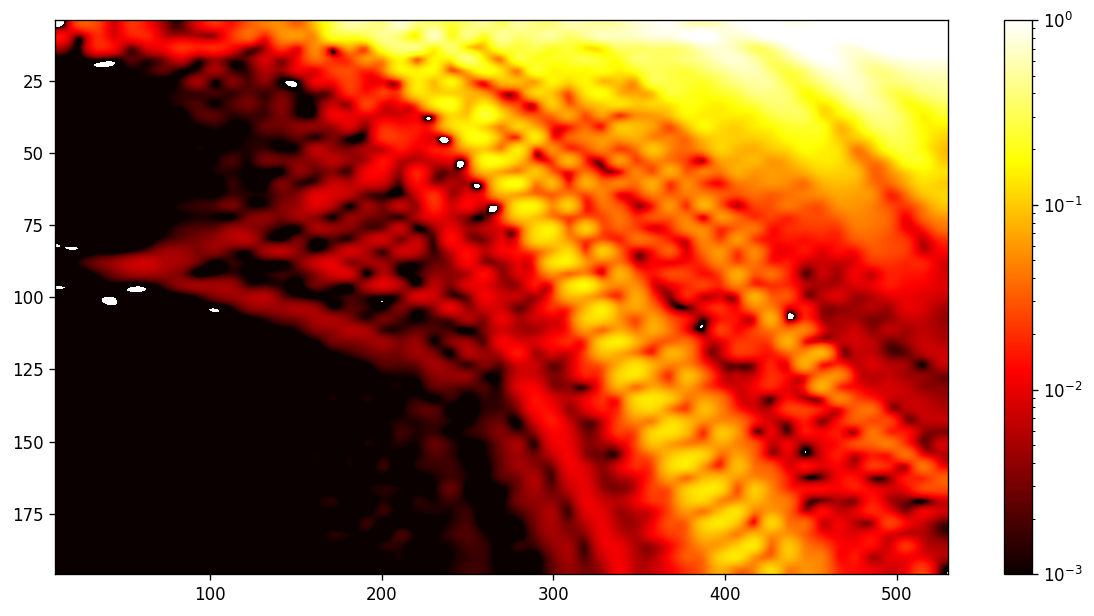

[[0.00000000e+00 3.57143670e-03 1.45872337e-03 ... 2.66175849e-05
  2.63410154e-05 2.55450836e-05]
 [1.18239010e-02 3.18076619e-03 5.74674960e-03 ... 1.35488585e-04
  1.22549507e-04 1.12020266e-04]
 [1.44948621e-02 7.48892673e-03 6.10757376e-03 ... 1.07663066e-04
  1.19206504e-04 1.32479953e-04]
 ...
 [9.57598201e-01 1.15076623e+00 8.54728005e-01 ... 8.34359635e-03
  6.51793997e-03 1.18924941e-02]
 [9.82905621e-01 1.12465462e+00 8.57838278e-01 ... 4.37971776e-03
  8.35254205e-03 9.55387287e-03]
 [9.48270502e-01 1.09346036e+00 8.08616455e-01 ... 1.80159910e-03
  4.64494366e-03 2.72941745e-03]]


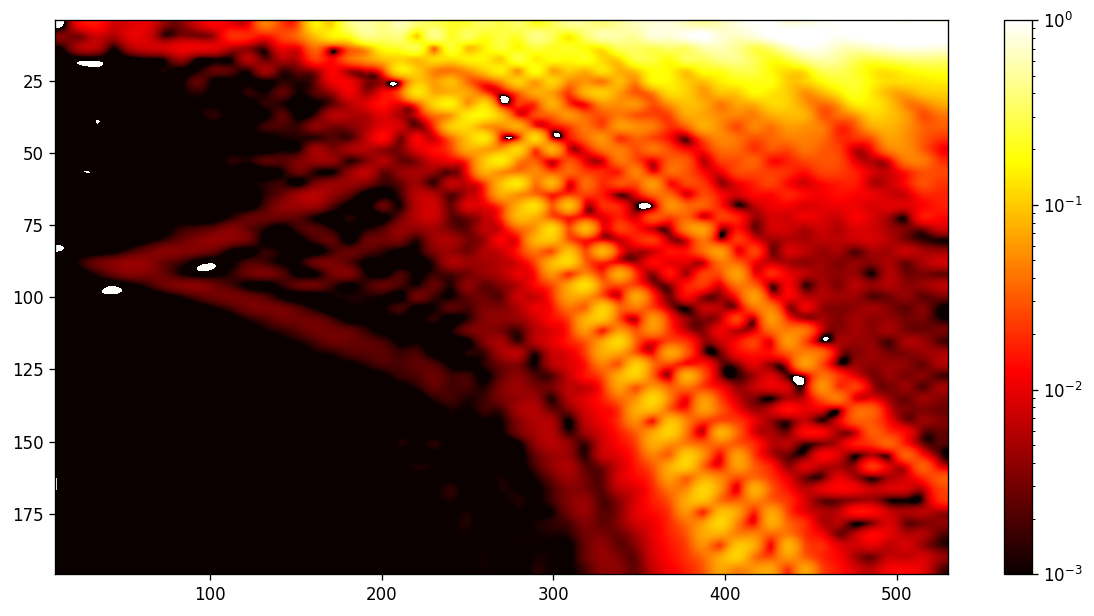

[[0.00000000e+00 1.30967265e-03 2.59303122e-03 ... 6.33039366e-05
  6.41043884e-05 6.42569940e-05]
 [3.38241291e-03 2.35641226e-03 1.00025245e-03 ... 6.76533504e-05
  6.79248702e-05 6.74866146e-05]
 [2.65841794e-03 4.16311430e-03 2.77608238e-03 ... 3.48330367e-05
  3.38377491e-05 3.46277068e-05]
 ...
 [6.93963955e-02 1.12495902e-01 7.84111255e-02 ... 1.21871362e-03
  5.11717353e-03 8.61133781e-03]
 [6.10939886e-02 1.11444198e-01 5.83558461e-02 ... 5.42476796e-03
  4.77550338e-03 2.51563881e-03]
 [4.53580783e-02 9.43937007e-02 4.04526560e-02 ... 3.29009797e-03
  3.62410244e-03 2.66678751e-03]]


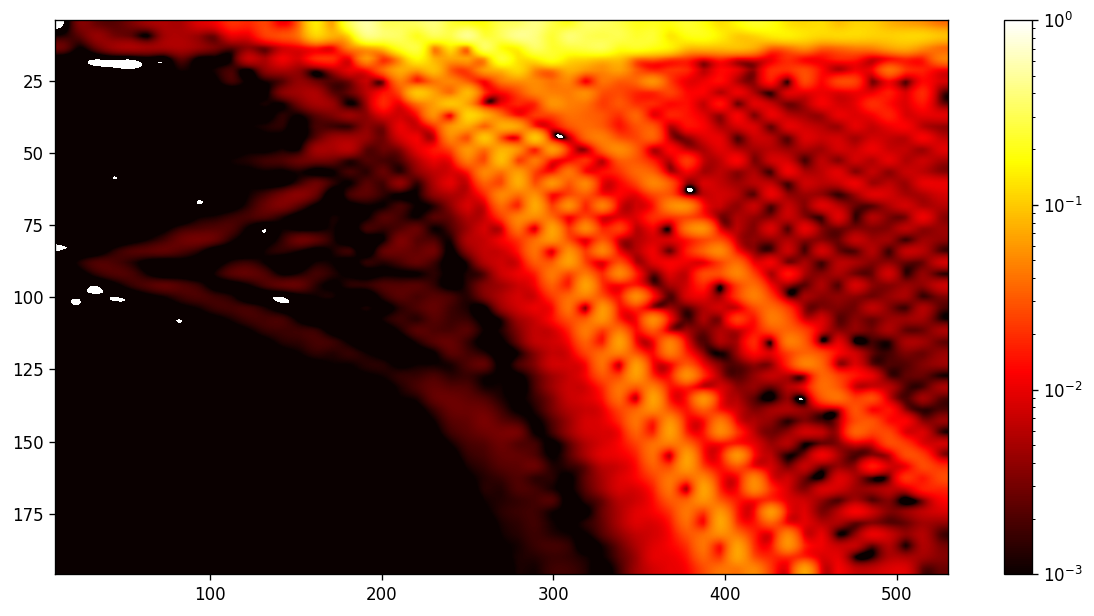

In [15]:
plot_fluence_var_map(rxFluence_arr0, rxList_ppp0)
plot_fluence_var_map(rxFluence_arr2, rxList_ppp2)
plot_fluence_var_map(rxFluence_arr1, rxList_ppp1)